# Data Reshaping & Analysis with Pandas

This notebook demonstrates the core pandas workflow for **reshaping data** (wide ⇄ long),
**aggregating** with `groupby`, and **visualizing** trends with seaborn.

**Contents**

1. **Grades dataset** — transforming data from wide to long format with `pd.melt()`
2. **UK baby names dataset** — multi-step analysis: totals by year/sex, pivoting, ratios, and three line plots


## Setup

Import the libraries we need for data manipulation and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

## Section 1: Grades Dataset — Transforming Data from Wide to Long Format

**Wide format** puts every variable in its own column (one column per assignment type).
**Long format** stacks those measurements into two columns: an identifier of *what* was
measured and the *value* itself.

Long format is what pandas needs for grouped aggregation and for most seaborn plots,
so `pd.melt()` is one of the most common first steps when preparing data.

In this section we:

1. Build a small sample grades dataset (wide format)
2. Melt it into long format with `pd.melt()`
3. Compute per-assignment summary statistics with `.groupby().agg()`

In [2]:
# Create a sample dataset of student grades
# Each row represents one student, each column represents a different assignment type
data = {
    'student_id': [2457625, 1758293, 1622247],      # Unique identifier for each student
    'final_exam': [79, 92, 71],                     # Final exam scores
    'midterm': [68, 73, 87],                        # Midterm exam scores
    'individual_project': [71, 67, 74],             # Individual project scores
    'group_project': [83, 56, 77]                   # Group project scores
}

# Convert our dictionary into a pandas DataFrame
# This creates a "wide" format where each assignment type is its own column
grades_df = pd.DataFrame(data)

# Display the original wide format for comparison
print("--- Original (Wide) DataFrame ---")
print(grades_df)

--- Original (Wide) DataFrame ---
   student_id  final_exam  midterm  individual_project  group_project
0     2457625          79       68                  71             83
1     1758293          92       73                  67             56
2     1622247          71       87                  74             77


### Wide → Long with `pd.melt()`

- `id_vars` — columns to keep as identifiers (they are *not* melted)
- `var_name` — name of the new column holding the old column names
- `value_name` — name of the new column holding the values

In [3]:
# Transform from "wide" to "long" format using pd.melt()
long_grades_df = pd.melt(
    grades_df,                          # The DataFrame to transform
    id_vars=['student_id'],             # Columns to keep as identifiers (don't melt these)
    var_name='assignment_type',         # Name for the new column that will contain the old column names
    value_name='score'                  # Name for the new column that will contain the values
)

# Display the transformed long format
print("--- Transformed (Long) DataFrame ---")
print(long_grades_df)

--- Transformed (Long) DataFrame ---
    student_id     assignment_type  score
0      2457625          final_exam     79
1      1758293          final_exam     92
2      1622247          final_exam     71
3      2457625             midterm     68
4      1758293             midterm     73
5      1622247             midterm     87
6      2457625  individual_project     71
7      1758293  individual_project     67
8      1622247  individual_project     74
9      2457625       group_project     83
10     1758293       group_project     56
11     1622247       group_project     77


### Summary Statistics by Assignment Type

With the data in long format, a single `.groupby().agg()` chain produces per-assignment
statistics — the same pattern used throughout Section 2.

In [4]:
# Calculate summary statistics for each assignment type
summary_stats = (long_grades_df
                 .groupby('assignment_type')['score']    # Group by assignment, focus on score column
                 .agg(                                   # Apply multiple aggregation functions
                     min_score='min',                    # Minimum score for this assignment type
                     max_score='max',                    # Maximum score for this assignment type
                     mean_score='mean',                  # Average score for this assignment type
                     std_dev='std'                       # Standard deviation (spread of scores)
                 )
                 .reset_index()                          # Convert back to regular DataFrame
                )

print("--- Summary Statistics by Assignment Type ---")
print(summary_stats)

--- Summary Statistics by Assignment Type ---
      assignment_type  min_score  max_score  mean_score    std_dev
0          final_exam         71         92   80.666667  10.598742
1       group_project         56         83   72.000000  14.177447
2  individual_project         67         74   70.666667   3.511885
3             midterm         68         87   76.000000   9.848858


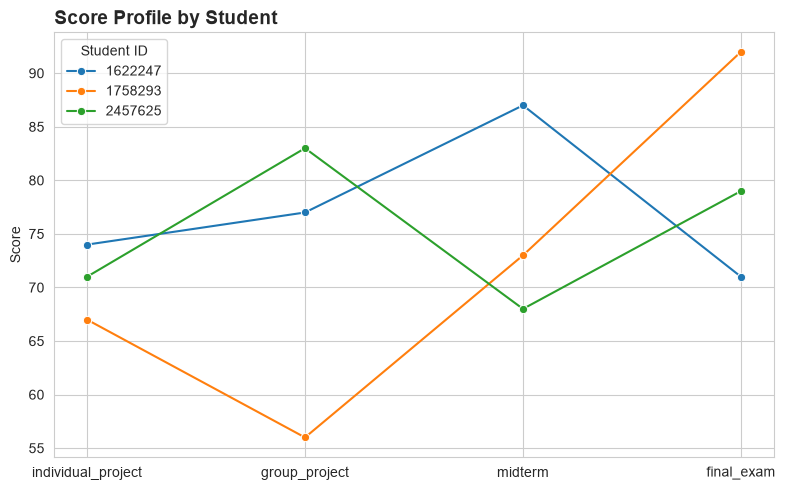

In [20]:
order = ['individual_project', 'group_project', 'midterm', 'final_exam']

long_grades_df['assignment_type'] = pd.Categorical(
    long_grades_df['assignment_type'],
    categories=order,
    ordered=True
)

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

ax = sns.lineplot(data=long_grades_df,
                  x='assignment_type', y='score',
                  hue='student_id', 
                  marker='o',
                  palette='tab10')

ax.set_title('Score Profile by Student', fontsize=14, fontweight='bold', loc='left')
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.legend(title='Student ID')
plt.tight_layout()
plt.show()

## Section 2: UK Baby Names Dataset — Analysis & Visualization

Now a larger, real-world dataset: baby name popularity in the UK over time.
Each row records how many babies of a given sex received a given name in a given year.

We'll work through a typical analysis sequence:

| Step | What we compute | Key pandas tools |
|---|---|---|
| 1 | Total births across all years | `.sum()` |
| 2 | Total births per year | `.groupby().agg()` |
| 3 | Births per year **and** sex → % boys | `.pivot()`, `.assign()` |
| 4 | Unique names per year and sex | `.nunique()` |
| 5 | Female-to-male unique-name ratio | `.pivot()`, `.assign()` |

Each analysis step feeding a chart is followed by its seaborn line plot.

### Loading and Inspecting the Data


In [5]:
# Load the UK baby names dataset from a CSV file
babynames = pd.read_csv('../data/ukbabynames.csv')

# Display the first 10 rows to understand the data structure
print(babynames.head(10))

# Show information about the dataset structure and data types
print("\n--- Dataset Information ---")
print(babynames.info())

   year sex       name     n  rank           nation
0  1996   F     SOPHIE  7087     1  England & Wales
1  1996   F      CHLOE  6824     2  England & Wales
2  1996   F    JESSICA  6711     3  England & Wales
3  1996   F      EMILY  6415     4  England & Wales
4  1996   F     LAUREN  6299     5  England & Wales
5  1996   F     HANNAH  5916     6  England & Wales
6  1996   F  CHARLOTTE  5866     7  England & Wales
7  1996   F    REBECCA  5828     8  England & Wales
8  1996   F        AMY  5206     9  England & Wales
9  1996   F      MEGAN  4948    10  England & Wales

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565817 entries, 0 to 565816
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   year    565817 non-null  int64 
 1   sex     565817 non-null  object
 2   name    565816 non-null  object
 3   n       565817 non-null  int64 
 4   rank    565817 non-null  int64 
 5   nation  565817 non-null  

### Analysis 1–2: Total Births

First a single grand total, then a yearly breakdown using `groupby` + `agg`.

In [6]:
# ANALYSIS 1: Calculate total births across all years in the dataset
total_births_all_time = babynames['n'].sum()
print(f"Total births across all years: {total_births_all_time:,}")

# ANALYSIS 2: Calculate total births for each year
yearly_births = (babynames
                 .groupby('year')                       # Group by year
                 .agg({'n': 'sum'})                     # Sum the birth counts
                 .reset_index()                         # Convert back to DataFrame
                )

print("\n--- Total Births by Year ---")
print(yearly_births)

Total births across all years: 18,676,539

--- Total Births by Year ---
    year       n
0   1974   70001
1   1975   67862
2   1976   64829
3   1977   62272
4   1978   64252
5   1979   68327
6   1980   68841
7   1981   69021
8   1982   66165
9   1983   65070
10  1984   65092
11  1985   66663
12  1986   65806
13  1987   66234
14  1988   66205
15  1989   63478
16  1990   65967
17  1991   67022
18  1992   65787
19  1993   63334
20  1994   61653
21  1995   60049
22  1996  673809
23  1997  689372
24  1998  678886
25  1999  661181
26  2000  639337
27  2001  628540
28  2002  626596
29  2003  650374
30  2004  668675
31  2005  672446
32  2006  696358
33  2007  717354
34  2008  738387
35  2009  733139
36  2010  748913
37  2011  748278
38  2012  750918
39  2013  719468
40  2014  716955
41  2015  717504
42  2016  714532
43  2017  694748
44  2018  671951
45  2019  653015
46  2020  621873


### Analysis 3: Births by Year and Sex → Percentage of Boys

Grouping by **two** keys (`year`, `sex`) gives separate male/female totals.
Then we do the reverse of melting — `.pivot()` spreads the `sex` values back out into
separate `F` and `M` columns (long → wide), which makes the percentage calculation a
simple column-wise formula inside `.assign()`.

In [7]:
# ANALYSIS 3: Calculate total births by year AND sex (boys vs girls)
births_by_year_sex = (babynames
                      .groupby(['year', 'sex'])         # Group by both year and sex
                      .agg(total_births=('n', 'sum'))   # Sum births, name the result 'total_births'
                      .reset_index()                    # Convert back to DataFrame
                     )

print("\n--- Total Births by Year and Sex ---")
print(births_by_year_sex)


--- Total Births by Year and Sex ---
    year sex  total_births
0   1974   F         34228
1   1974   M         35773
2   1975   F         32897
3   1975   M         34965
4   1976   F         31364
..   ...  ..           ...
89  2018   M        349302
90  2019   F        313134
91  2019   M        339881
92  2020   F        299439
93  2020   M        322434

[94 rows x 3 columns]


In [8]:
# ANALYSIS 3a: Calculate the percentage of boys born each year
# Reshape data so 'F' and 'M' become separate columns
births_by_year_sex_wide = (births_by_year_sex
    .pivot(index='year',                     # Rows will be years
           columns='sex',                    # Columns will be 'F' and 'M'
           values='total_births')
    )

pct_boys_df = (births_by_year_sex_wide
               # lambda df creates a temporary function that calculates the percentage
               .assign(pct_boys=lambda df: (df['M'] / (df['F'] + df['M'])) * 100)
               .reset_index()                           # Convert back to regular DataFrame
              )

print("\n--- Percentage of Boys by Year ---")
print(pct_boys_df.head())


--- Percentage of Boys by Year ---
sex  year      F      M   pct_boys
0    1974  34228  35773  51.103556
1    1975  32897  34965  51.523680
2    1976  31364  33465  51.620417
3    1977  30318  31954  51.313592
4    1978  31221  33031  51.408516


#### 📈 Visualization 1 — Percentage of Boys Born Each Year

A seaborn line plot with the y-axis formatted as percentages via matplotlib's
`PercentFormatter` (note: it expects *fractions*, so values are divided by 100).

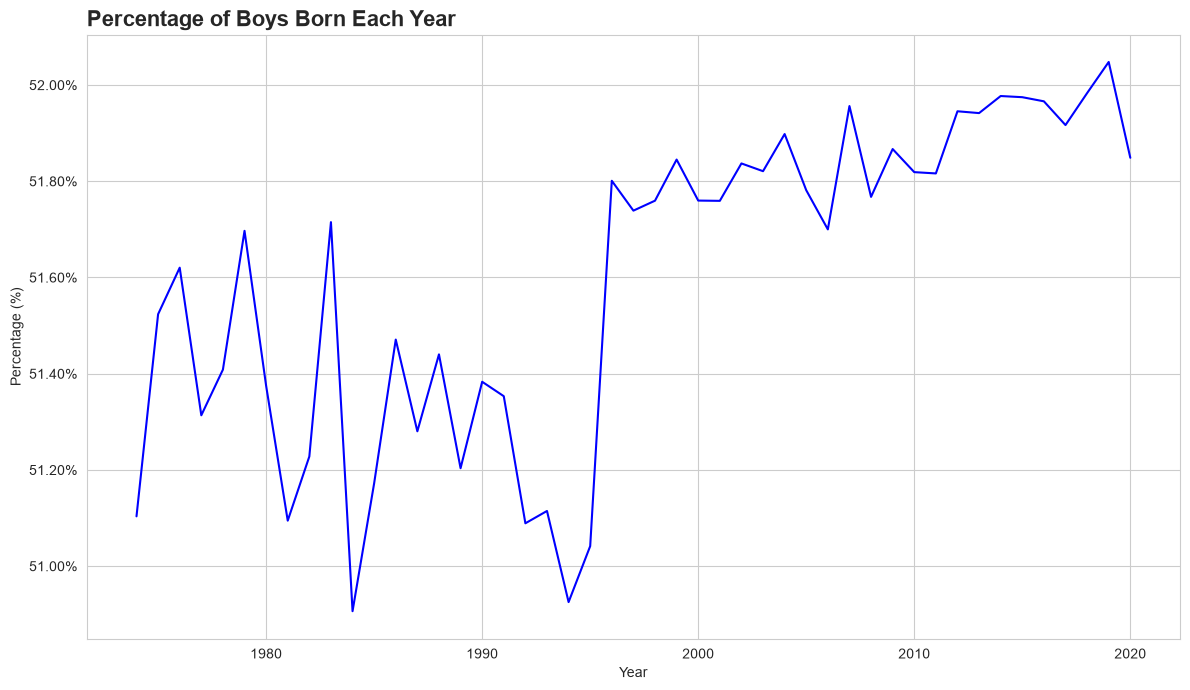

In [9]:
# Set up the plot size and style
plt.figure(figsize=(12, 7))                          # Create a wide figure for time series
sns.set_style("whitegrid")                           # Use seaborn's clean grid style

ax = sns.lineplot(data=pct_boys_df,                  # Use our calculated percentage data
                  x='year',                          # Years on x-axis
                  y='pct_boys',                      # Percentage of boys on y-axis
                  color='blue')                      # Blue line color

ax.set_title('Percentage of Boys Born Each Year',    # Main title
             fontsize=16,
             fontweight='bold',
             loc='left')                             # Left-align title
ax.set_ylabel("Percentage (%)")                     # Y-axis label
ax.set_xlabel("Year")                               # X-axis label

# Format the y-axis to show percentage signs
ax.yaxis.set_major_formatter(PercentFormatter())

plt.tight_layout()
plt.show()

### Analysis 4: Unique Names by Year and Sex

How many *different* names were used each year for boys vs girls?
`.nunique()` counts distinct values per group.

In [10]:
unique_names_df = (babynames
                   .groupby(['year', 'sex'])              # Group by year and sex
                   .agg(unique_names=('name', 'nunique')) # Count unique names (nunique = number of unique)
                   .reset_index()                       # Convert back to DataFrame
                  )

print("\n--- Unique Names by Year and Sex ---")
print(unique_names_df.head())


--- Unique Names by Year and Sex ---
   year sex  unique_names
0  1974   F          1970
1  1974   M          1167
2  1975   F          2007
3  1975   M          1169
4  1976   F          2023


#### 📈 Visualization 2 — Unique Names Over Time

Using `hue='sex'` splits the data into two lines automatically, and `palette`
controls their colors.

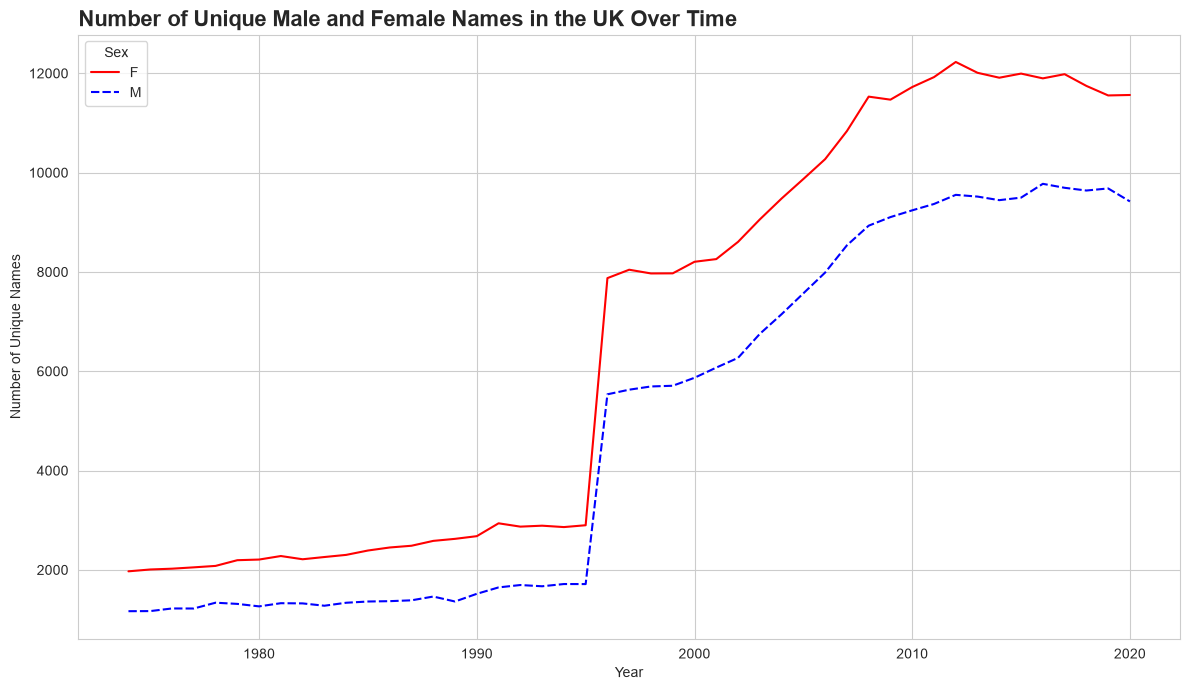

In [11]:
# Create a color mapping to control the line colors
color_palette = {'M': 'blue', 'F': 'red'}          # Boys = blue, Girls = red

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.lineplot(data=unique_names_df,
                  x='year',                          # Years on x-axis
                  y='unique_names',                  # Number of unique names on y-axis
                  hue='sex',                         # Create separate lines for M and F
                  style='sex',                       # Give lines different styles (optional)
                  palette=color_palette)             # Use our custom colors

ax.set_title('Number of Unique Male and Female Names in the UK Over Time',
             fontsize=16,
             fontweight='bold',
             loc='left')                             # Left-align title
ax.set_ylabel("Number of Unique Names")              # Y-axis label
ax.set_xlabel("Year")                               # X-axis label
ax.legend(title='Sex')                              # Improve legend title

plt.tight_layout()
plt.show()

### Analysis 5: Female-to-Male Unique-Name Ratio

Pivot the unique-name counts wide, then divide. A ratio **> 1** means more unique
girl names than boy names that year; **< 1** means the opposite.

In [12]:
ratio_df = (unique_names_df
            # Step 1: Reshape data so F and M counts are in separate columns
            .pivot(index='year',                     # Rows will be years
                   columns='sex',                    # Columns will be 'F' and 'M'
                   values='unique_names')            # Values will be unique name counts

            # Step 2: Calculate the ratio of female to male unique names
            .assign(ratio=lambda df: df['F'] / df['M'])
            .reset_index()                           # Convert back to regular DataFrame
           )

print("\n--- Ratio of Female to Male Unique Names ---")
print(ratio_df.head())


--- Ratio of Female to Male Unique Names ---
sex  year     F     M     ratio
0    1974  1970  1167  1.688089
1    1975  2007  1169  1.716852
2    1976  2023  1222  1.655483
3    1977  2050  1221  1.678952
4    1978  2079  1338  1.553812


#### 📉 Visualization 3 — Ratio Over Time

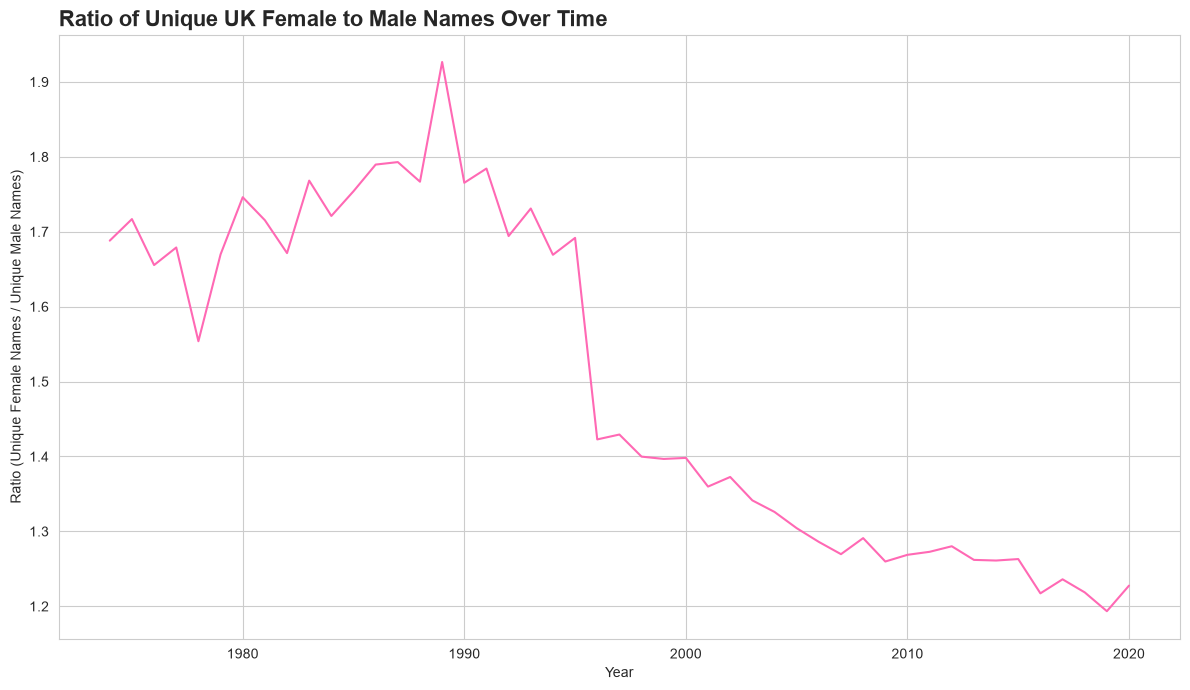

In [13]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.lineplot(data=ratio_df,
                  x='year',                          # Years on x-axis
                  y='ratio',                         # Female/Male ratio on y-axis
                  color='hotpink')                   # Pink color for the line

ax.set_title('Ratio of Unique UK Female to Male Names Over Time',
             fontsize=16,
             fontweight='bold',
             loc='left')                             # Left-align title
ax.set_ylabel("Ratio (Unique Female Names / Unique Male Names)")  # Descriptive y-axis label
ax.set_xlabel("Year")                               # X-axis label

plt.tight_layout()
plt.show()

## Key Concepts Demonstrated

**1. Data reshaping**
- `pd.melt()` — wide → long
- `.pivot()` — long → wide

**2. Data aggregation**
- `.groupby()` — group by one or more columns
- `.agg()` — apply functions (sum, mean, count, …) to grouped data
- `.nunique()` — count unique values in a column

**3. Data manipulation**
- `.assign()` — add new calculated columns
- `.reset_index()` — convert grouped data back to a regular DataFrame
- `lambda` functions — simple inline calculations

**4. Visualization with seaborn**
- `sns.lineplot()` — line plots with automatic styling
- `hue` — separate lines per category
- `palette` — control colors
- matplotlib integration (`PercentFormatter`, titles, labels) for customization